# Presenting Game Results

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import requests
import seaborn as sns

## Loading game result data

In [26]:
df = pd.read_csv("game-results.csv", index_col=1, parse_dates=True, header=None, names=["Game Version", "Date", "Time Survived", "Score"])

## What data is stored and why
<hr>

### Game Version

Changes to the game may effect how scores are calculated or how much score a player get during a game.
As such we need the game version to group results by as to not make all results from a previous version effect results from a newer one.

### Date

This is the date time the results was set and is the id for each row.

### Time Survived

How long the run lasted in seconds

### Score


Checking the data is here

In [13]:
df.head()

,Game Version,Time Survived,Score
Date,,,
2026-08-11 22:02:53.976116,2026-08-10 23:55:20.054130,10.757392,260
2026-08-11 22:03:49.405594,2026-08-10 23:55:20.054130,24.408522,933
2026-08-11 22:07:52.788656,2026-08-10 23:55:20.054130,1.700332,31
2026-08-11 22:08:16.921228,2026-08-10 23:55:20.054130,12.781978,340
2026-08-11 22:09:49.791919,2026-08-10 23:55:20.054130,0.995767,17


In [27]:
df["Game Version"].unique()

<StringArray>
['2026-08-10 23:55:20.054130', '2026-08-18 16:39:23.234698']
Length: 2, dtype: str

# Grouping Results by Game Version
<hr>

First as the game version's are a date they will be changed to a number in order of the game version's creation.

version_map is created incase the date the versions are created needs to be referenced in the future. e.g. if it is know the scoring wouldn't have been effected between 2 versions they could be remerged

In [28]:
version = pd.Series(df["Game Version"].unique()).sort_values().reset_index(drop=True)

version_map = pd.Series( range(1, len(version)+1), index = version)

df["Game Version"] = df["Game Version"].map(version_map)

df.head()


,Game Version,Time Survived,Score
Date,,,
2026-08-11 22:02:53.976116,1,10.757392,260
2026-08-11 22:03:49.405594,1,24.408522,933
2026-08-11 22:07:52.788656,1,1.700332,31
2026-08-11 22:08:16.921228,1,12.781978,340
2026-08-11 22:09:49.791919,1,0.995767,17


Next a dictionary is created which will contain a dataframe of the Date, Time Survived and Score for each individual Game Version


In [29]:
dfs = {}

for version in df["Game Version"].unique():
    dfs[version] = df[df["Game Version"] == version][
        [ "Time Survived", "Score"]
    ].copy()

# Grouping by Time Survived and Score
<hr>

In [35]:
time_bins = [0, 10, 30, 60, 90, float("inf")]
time_labels = ["< 10 seconds", "10–29 seconds", "30–59 seconds", "60-89 seconds", "90+ seconds"]

score_bins = [0, 100, 500, 1000, 5000, 10000, 50000, float("inf")]
score_labels = ["< 100 points", "100-499 points", "500-999 points", "1000-4999 points", "5000-9999 points", "10000-49999 points", ">50000 points"]

In [39]:
for version, game_df in dfs.items():
    game_df["Survival Group"] = pd.cut(game_df["Time Survived"], bins=time_bins, labels=time_labels, right=False)

    game_df["Points Group"] = pd.cut(game_df["Score"], bins=score_bins, labels=score_labels, right=False)


# Creating Graphs
<hr>

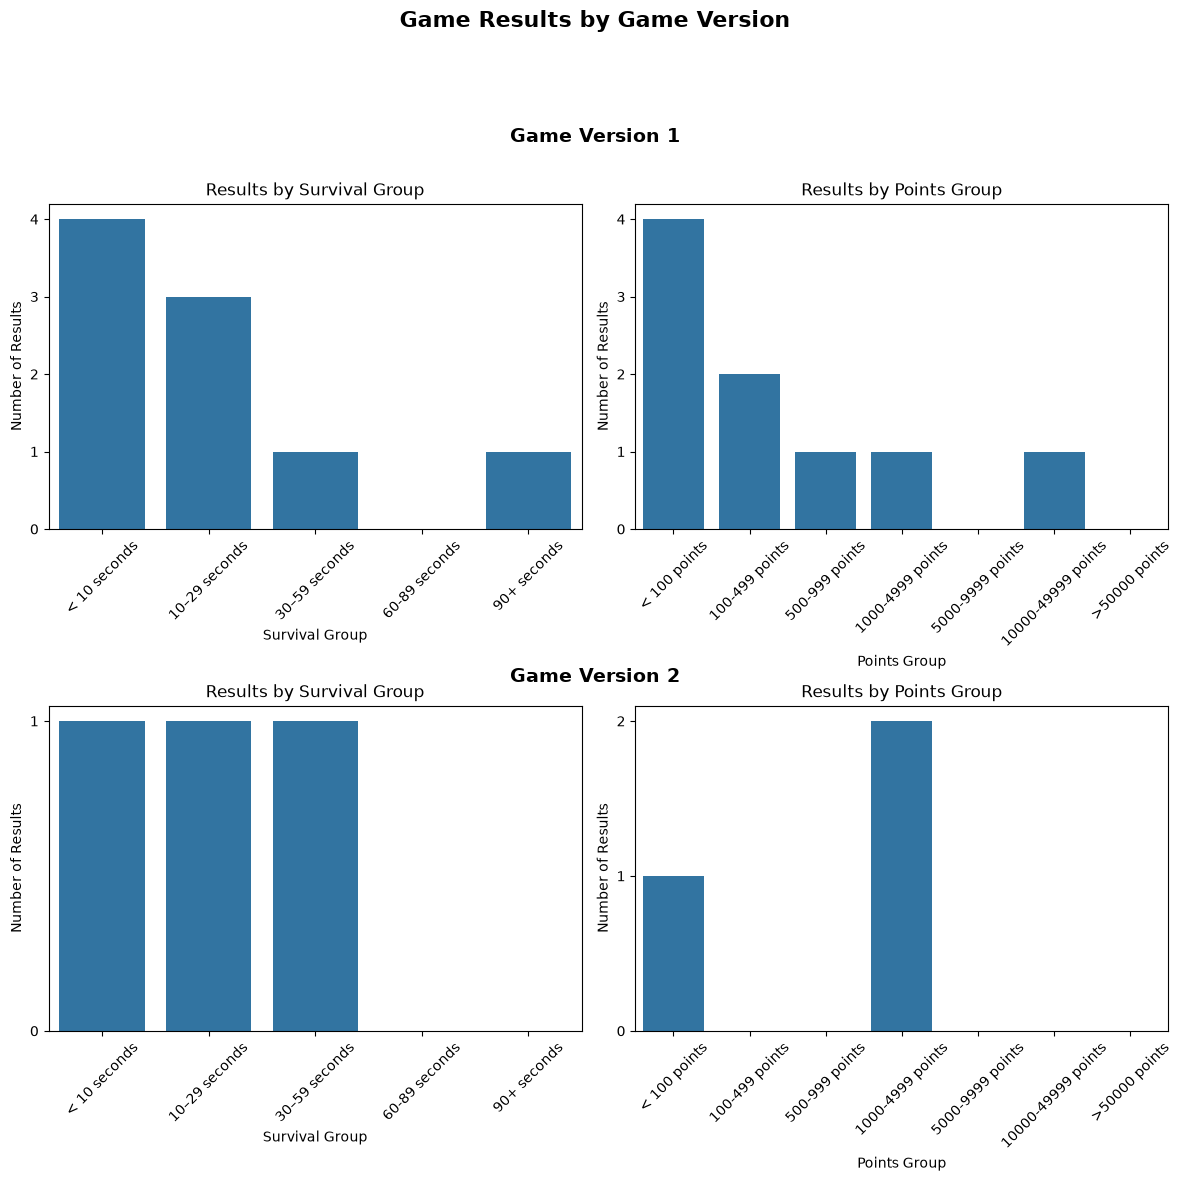

In [70]:
fig, axes = plt.subplots(len(dfs), 2, figsize=(12, 6*len(dfs)))

fig.suptitle("Game Results by Game Version", fontsize=16,fontweight="bold")

for row, (version, game_df) in enumerate(dfs.items()):

    # Survival Group
    sns.countplot(
        data=game_df,
        x="Survival Group",
        ax=axes[row, 0]
    )
    axes[row, 0].set_xlabel("Survival Group")
    axes[row, 0].set_ylabel("Number of Results")
    axes[row, 0].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[row, 0].set_title("Results by Survival Group")
    axes[row, 0].tick_params(axis="x", rotation=45)

    # Points Group
    sns.countplot(
        data=game_df,
        x="Points Group",
        ax=axes[row, 1]
    )
    axes[row, 1].set_xlabel("Points Group")
    axes[row, 1].set_ylabel("Number of Results")
    axes[row, 1].yaxis.set_major_locator(MaxNLocator(integer=True))
    axes[row, 1].set_title("Results by Points Group")
    axes[row, 1].tick_params(axis="x", rotation=45)

    y_position = 0.87 - row * (.9 / len(dfs))
    
    # Game Version above the row
    fig.text(
        0.5,
        y_position,
        f"Game Version {version}",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()
    